In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile
import xarray as xr

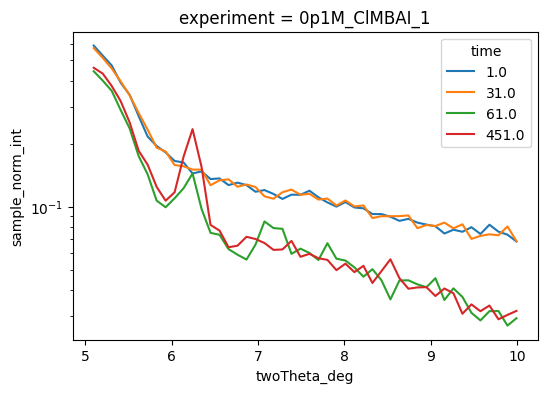

In [2]:
pdataset = xr.open_dataset(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined.nc")

pdataset = pdataset.swap_dims({"q_A^-1": "twoTheta_deg"})

sample_1 = pdataset.isel(experiment=0)

fig, ax = plt.subplots(figsize=(6,4))

sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5, 10)).dropna("time").sel(time=[0, 30, 60, 450], method='nearest').plot.line(x="twoTheta_deg", ax=ax)
ax.set_yscale("log")

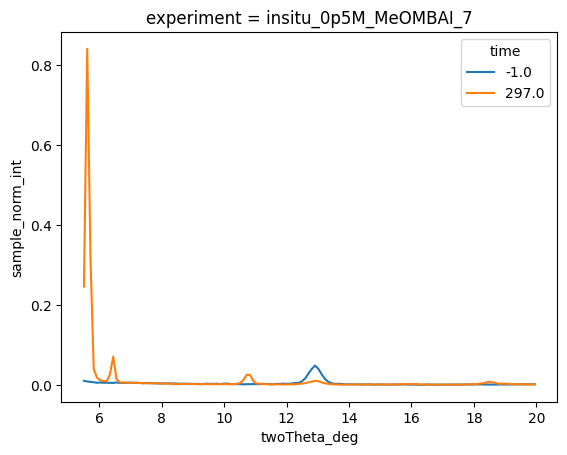

In [3]:
pdataset["sample_norm_int"] \
    .loc[dict(experiment='insitu_0p5M_MeOMBAI_7')]\
    .dropna(dim="time")\
    .sel(time=[0, 300], method='nearest')\
    .sel(twoTheta_deg=slice(5.5, 20))\
    .plot.line(x="twoTheta_deg")



In [32]:
pdataset["sample_norm_int"] \
    .sel(dict(experiment='insitu_1p0M_MeOMBAI_6'))

<xarray.DataArray 'sample_norm_int' (time: 452, twoTheta_deg: 500)> Size: 904kB
[226000 values with dtype=float32]
Coordinates:
  * time          (time) float64 4kB -9.0 -7.0 -5.0 -3.0 ... 697.0 699.0 701.0
    frame         (time) int64 4kB ...
  * twoTheta_deg  (twoTheta_deg) float64 4kB 4.266 4.37 4.474 ... 58.53 58.65
    q_A^-1        (twoTheta_deg) float64 4kB 0.3037 0.3111 ... 3.989 3.996
    experiment    <U22 88B 'insitu_1p0M_MeOMBAI_6'
Attributes:
    0p1M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_MBAI_1:             {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p0M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p0M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p5M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p5M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_0p5M_MeOMBAI_7:   {"base_poni_file": "G:/Shared drives/Sutter-Fell...
    insitu_1p0M_ClMBAI_6re:  {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_1p0M_MBAI_5:      {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_1p0M_MeOMBAI_6:   {"base_poni_file": "G:/Shared drives/Sutter-Fell...

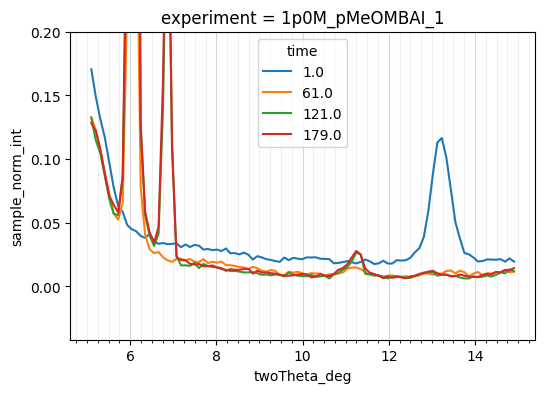

In [72]:
fig, ax = plt.subplots(figsize=(6,4))

pdataset["sample_norm_int"] \
    .sel(dict(experiment='1p0M_pMeOMBAI_1'))\
    .dropna(dim="time")\
    .shift(twoTheta_deg=0)\
    .sel(time=[0, 60, 120, 180], method='nearest')\
    .sel(twoTheta_deg=slice(5., 15))\
    .plot.line(x="twoTheta_deg", ax=ax)

ax.set_ylim(None, 0.2)
# use minor ticks for x-axis
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)


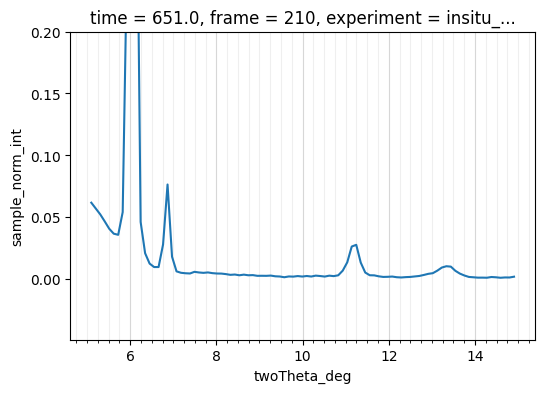

In [5]:
fig, ax = plt.subplots(figsize=(6,4))

pdataset["sample_norm_int"] \
    .sel(dict(experiment='insitu_0p5M_MeOMBAI_7'))\
    .dropna(dim="time")\
    .shift(twoTheta_deg= 4)\
    .isel(time=-1)\
    .sel(twoTheta_deg=slice(5., 15))\
    .plot.line(x="twoTheta_deg", ax=ax)

ax.set_ylim(None, 0.2)
# use minor ticks for x-axis
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)


Voigt Fit Parameters for peak at 6.24°:
  Amplitude: 0.019
  Center: 6.243°
  Sigma: 0.078
  Gamma: 0.008
  Slope: -0.055
  Offset: 0.023

Voigt Fit Parameters for peak at 6.97°:
  Amplitude: 0.368
  Center: 7.471°
  Sigma: 0.496
  Gamma: 0.000
  Slope: -0.291
  Offset: -0.313

Voigt Fit Parameters for peak at 7.70°:
  Amplitude: 0.002
  Center: 7.763°
  Sigma: 0.091
  Gamma: 0.000
  Slope: -0.005
  Offset: 0.008

Voigt Fit Parameters for peak at 8.22°:
  Amplitude: 0.000
  Center: 8.263°
  Sigma: 0.363
  Gamma: 1.042
  Slope: -0.004
  Offset: 0.009

Voigt Fit Parameters for peak at 11.56°:
  Amplitude: 0.010
  Center: 11.534°
  Sigma: 0.000
  Gamma: 0.258
  Slope: -0.000
  Offset: -0.000

Voigt Fit Parameters for peak at 13.34°:
  Amplitude: 0.117
  Center: 13.348°
  Sigma: 0.241
  Gamma: 0.000
  Slope: -0.000
  Offset: -0.002



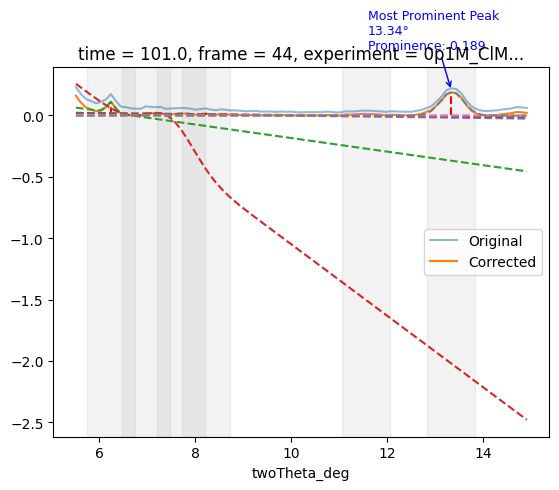

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import analysis
import importlib
importlib.reload(analysis)
from analysis import (
    baseline_correction,
    find_peaks_in_window,
    voigt_profile_func,
    voigt_fit
)

sample_1_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 15)).dropna('time').sel(time=100, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

# fig, ax = plt.subplots(figsize=(6,4))
sample_1_da.plot(label='Original', alpha=0.5)
corrected.plot(label='Corrected')
# calc_baseline.plot(label='Baseline', linestyle=':', alpha=0.7)
plt.legend()
# plt.ylim(None, 0.15)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.01
)

plt.vlines(peaks_x, ymin=0, ymax=peaks_intensities, color='red', linestyle='--', label='Detected Peaks')

# get the most prominent peak
if properties:
    prominences = [prop['prominences'] for prop in properties]
    max_prom_idx = np.argmax(prominences)
    peak_pos = peaks_x[max_prom_idx]
    peak_intensity = peaks_intensities[max_prom_idx]
    plt.annotate(
        f"Most Prominent Peak\n{peak_pos:.2f}°\nProminence: {prominences[max_prom_idx]:.3f}",
        xy=(peak_pos, max(0.2, peak_intensity)),
        xytext=(-60,30),
        textcoords='offset points',
        ha='left',
        fontsize=9,
        color='blue',
        arrowprops=dict(arrowstyle='->', color='blue')
    )
    
fitted_das = []
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0 
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", initial_guess=peak_pos, window_size=0.9, no_slope=no_slope)
        fitted_das.append(fitted_da)
    except RuntimeError as e:
        print(f"Voigt fit failed for peak at {peak_pos:.2f}°: {e}")
        continue
    fitted_da.plot(label=f'Voigt Fit at {peak_pos:.2f}°', linestyle='--')
    # print every property as .3f
    amp, cen, sigma, gamma, slope, offset = popt
    print(
        f"Voigt Fit Parameters for peak at {peak_pos:.2f}°:\n"
        f"  Amplitude: {amp:.3f}\n"
        f"  Center: {cen:.3f}°\n"
        f"  Sigma: {sigma:.3f}\n"
        f"  Gamma: {gamma:.3f}\n"
        f"  Slope: {slope:.3f}\n"
        f"  Offset: {offset:.3f}\n"
    )
    plt.axvspan(peak_pos - 0.5, peak_pos + 0.5, color='gray', alpha=0.1)

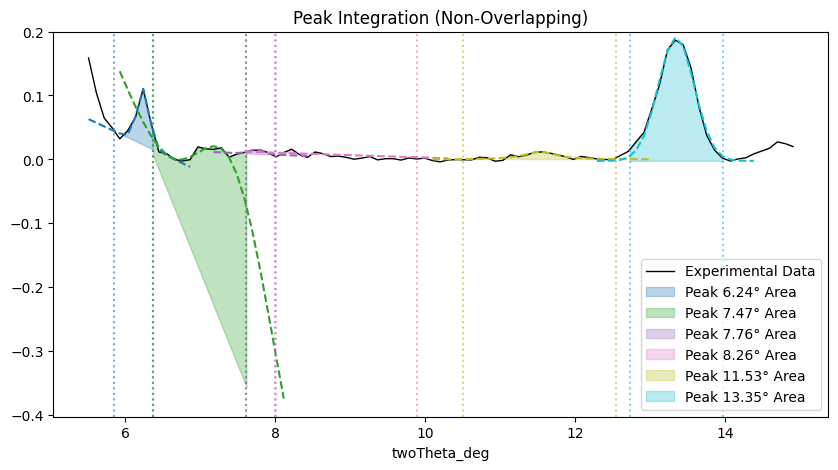

Peak Center  Area         Integration Range         Offset    
-----------------------------------------------------------------
6.243        0.01644      [5.859, 6.372]            0.023     
7.471        0.22989      [6.372, 7.617]            -0.313    
7.763        0.00142      [7.617, 7.998]            0.008     
8.263        -0.00432     [8.013, 9.899]            0.009     
11.534       0.00772      [10.504, 12.544]          -0.000    
13.348       0.11663      [12.729, 13.968]          -0.002    


In [37]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from analysis import calculate_peak_areas, voigt_fit, voigt_profile_func

# --- Usage (Re-run) ---

# 1. Collect fit results
collected_results = []
# print("Fitting peaks for area calculation...")
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", initial_guess=peak_pos, window_size=0.9, no_slope=no_slope)
        collected_results.append({'popt': popt, 'peak_pos': peak_pos})
    except RuntimeError:
        pass

# 2. Calculate areas (using 95% confidence)
areas_info = calculate_peak_areas(corrected, "twoTheta_deg", collected_results, confidence=0.99)

# 3. Visualization
plt.figure(figsize=(10, 5))
corrected.plot(label='Experimental Data', color='black', linewidth=1)

colors = plt.cm.tab10(np.linspace(0, 1, len(areas_info)))

for i, info in enumerate(areas_info):
    l, r = info['integration_range']
    cen = info['popt'][1]
    
    if len(info['popt']) == 6:
        offset = info['popt'][5] 
        slope = info['popt'][4]
    else:
        offset = 0
        slope = 0
        
    background_func = lambda x: slope * (x - cen) + offset

    color = colors[i]
    
    # Plot boundaries
    plt.axvline(l, linestyle=':', color=color, alpha=0.6)
    plt.axvline(r, linestyle=':', color=color, alpha=0.6)

    # Re-construct subset for plotting fill
    grid_x = np.linspace(l, r, 100) # simpler for plotting
    grid_y_data = corrected.interp({"twoTheta_deg": grid_x}).values
    subset = xr.DataArray(grid_y_data, coords={"twoTheta_deg": grid_x}, dims=["twoTheta_deg"])
    
    # Shade integration area (data - background)
    bg_vals = background_func(subset.twoTheta_deg)
    
    plt.fill_between(subset.twoTheta_deg, subset, bg_vals, 
                     where=(subset > bg_vals),
                     alpha=0.3, color=color, label=f'Peak {cen:.2f}° Area')
    
    # plot the fitted Voigt profile
    subset_x_fit = corrected.sel(**{"twoTheta_deg": slice(l-0.5, r+0.5)})["twoTheta_deg"].values
    if len(subset_x_fit) > 0:
        fitted_curve = voigt_profile_func(subset_x_fit, *info['popt'])
        plt.plot(subset_x_fit, fitted_curve, linestyle='--', color=color)

plt.legend()
plt.title("Peak Integration (Non-Overlapping)")
plt.ylim(None, 0.2)
plt.show()

# 4. Print Results
print(f"{'Peak Center':<12} {'Area':<12} {'Integration Range':<25} {'Offset':<10}")
print("-" * 65)
for info in areas_info:
    l, r = info['integration_range']
    if len(info['popt']) == 6:
        off = info['popt'][5]
    else:
        off = 0
    print(f"{info['popt'][1]:<12.3f} {info['area']:<12.5f} {f'[{l:.3f}, {r:.3f}]':<25} {off:<10.3f}")

In [7]:
sample_1 = pdataset.isel(experiment=2)

# 1. Select the time series data
time_series_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(0, 300))
times = time_series_da.time.values

sample_1_da = time_series_da.sel(time=1, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.005
)

print(f"Identified peaks at positions: {peaks_x}")

Identified peaks at positions: [10.82790171 13.23131532]


In [8]:
pdataset.experiment.values

array(['0p1M_ClMBAI_1', '0p5M_ClMBAI_1', '0p5M_MBAI_1', '0p5M_pMeOMBAI_1',
       '1p0M_ClMBAI_1', '1p0M_pMeOMBAI_1', '1p5M_ClMBAI_1',
       '1p5M_pMeOMBAI_1', 'insitu_0p5M_MeOMBAI_7',
       'insitu_1p0M_ClMBAI_6re', 'insitu_1p0M_MBAI_5',
       'insitu_1p0M_MeOMBAI_6'], dtype=object)

In [ ]:
import analysis
import importlib
importlib.reload(analysis)
from analysis import process_time_series
import re
from pathlib import Path

peaks_of_interest_with_phase = {
    "MBAI": [(6.9, 2, "2D (002)"), (13.3, 2, "PbI2")],
    "ClMBAI": [(6.1, 2, "2D (002)"), (13.3, 2, "PbI2")],
    "p?MeOMBAI": [(6.1, 0.5, "2D (002)"), (13.3, 2, "PbI2"), (7.0, 0.5, "MeOMBAI")]
}

# Manual shift correction for known misalignment
global_shift_corrections = {
    "1p5M_pMeOMBAI_1": -5,
    "insitu_0p5M_MeOMBAI_7": 5,
    "insitu_1p0M_MeOMBAI_6": 5
}


result_dfs = {}

for experiment in pdataset.experiment.values:
    print(f"\n=== Processing Experiment: {experiment} ===")
    # 1. Select the time series data
    time_series_ds = pdataset.sel(experiment=experiment)
    time_series_da = time_series_ds["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(None, 300)).dropna(dim="time")

    global_shift = global_shift_corrections.get(experiment, 0)
    if global_shift != 0:
        time_series_da = time_series_da.shift(twoTheta_deg=global_shift)

    else:
        continue

    # Defined peaks of interest: (center_position, window_size)
    for k, v in peaks_of_interest_with_phase.items():
        regexp = re.compile(f"M_{k}", re.IGNORECASE)
        if regexp.search(experiment):
            # remove phase name for processing
            peaks_of_interest = [(pos, win) for pos, win, name in v]
            break
    
    if 'peaks_of_interest' not in locals():
        print(f"No peaks of interest defined for experiment: {experiment}. Skipping.")
        continue

    # 2. Run Analysis
    # Note: visualization of shifts is now saved to disk in time_series_results/experiment_1/visualized_step/
    df_evolution, warnings = process_time_series(
        time_series_da, 
        peaks_of_interest=peaks_of_interest, 
        sample_name=time_series_ds.experiment.values,
        output_dir=str(Path(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\time_series_results")),
        shift_threshold=0.3, 
        perform_baseline_correction=False, 
        debug=True
    )

    # 3. Report Results
    if warnings:
        print("\n--- Significant Peak Shifts Detected ---")
        for w in warnings:
            # Limit printing if too many
            if warnings.index(w) < 10:
                print(w)
        if len(warnings) > 10:
            print(f"... and {len(warnings)-10} more.")

    result_dfs[experiment] = df_evolution
    print("\n--- Evolution DataFrame Head ---")
    print(df_evolution.head())




=== Processing Experiment: 0p1M_ClMBAI_1 ===

=== Processing Experiment: 0p5M_ClMBAI_1 ===

=== Processing Experiment: 0p5M_MBAI_1 ===

=== Processing Experiment: 0p5M_pMeOMBAI_1 ===

=== Processing Experiment: 1p0M_ClMBAI_1 ===

=== Processing Experiment: 1p0M_pMeOMBAI_1 ===

=== Processing Experiment: 1p5M_ClMBAI_1 ===

=== Processing Experiment: 1p5M_pMeOMBAI_1 ===


Voigt fit failed for peak at 13.75: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 14.17: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.86: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.71: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.71: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.71: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.71: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 12.71: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for pea


--- Significant Peak Shifts Detected ---
Time -3.0s: Peak 13.3° -> 12.983° (shift 0.317)
Time -1.0s: Peak 13.3° -> 12.992° (shift 0.308)
Time 19.0s: Peak 13.3° -> 13.731° (shift 0.431)
Time 21.0s: Peak 13.3° -> 14.464° (shift 1.164)
Time 31.0s: Peak 13.3° -> 14.569° (shift 1.269)
Time 35.0s: Peak 13.3° -> 13.941° (shift 0.641)
Time 41.0s: Peak 13.3° -> 14.359° (shift 1.059)
Time 47.0s: Peak 13.3° -> 14.464° (shift 1.164)
Time 49.0s: Peak 13.3° -> 13.941° (shift 0.641)
Time 51.0s: Peak 7.0° -> 7.471° (shift 0.471)
... and 28 more.

--- Evolution DataFrame Head ---
Peak Center  6.3   7.0   7.5   12.1  12.2  12.3      13.0      13.1  13.5  \
Time                                                                        
-3.0          NaN   NaN   NaN   NaN   NaN   NaN  0.048765       NaN   NaN   
-1.0          NaN   NaN   NaN   NaN   NaN   NaN  0.053401       NaN   NaN   
 1.0          NaN   NaN   NaN   NaN   NaN   NaN       NaN  0.062736   NaN   
 3.0          NaN   NaN   NaN   NaN   NaN   

Voigt fit failed for peak at 13.65: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.65: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.75: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.02: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.02: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.13: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.02: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for pea


--- Significant Peak Shifts Detected ---
Time -3.0s: Peak 13.3° -> 13.688° (shift 0.388)
Time -1.0s: Peak 13.3° -> 13.687° (shift 0.387)
Time 1.0s: Peak 13.3° -> 13.666° (shift 0.366)
Time 3.0s: Peak 13.3° -> 13.656° (shift 0.356)
Time 109.0s: Peak 7.0° -> 7.575° (shift 0.575)
Time 111.0s: Peak 7.0° -> 7.575° (shift 0.575)

--- Evolution DataFrame Head ---
Peak Center      7.6       13.7
Time                           
-3.0              NaN  0.027663
-1.0              NaN  0.027992
 1.0              NaN  0.027434
 3.0              NaN  0.022650
 109.0       0.206608       NaN


In [30]:
import logging
import sys

# Configure logging to show INFO messages in the notebook output
logging.basicConfig(
    # stream=sys.stdout,
    level=logging.WARNING,
    # format='%(asctime)s - %(levelname)s - %(message)s',
    # force=True
)

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import re
import importlib
import analysis 

# Reload to get the new changes
importlib.reload(analysis)
from analysis import process_time_series_by_peak

# --- Configuration ---
# Format: (Center, Window, (Start_Index, Stop_Index), Name)
# Start_Index: Where to start tracking
# Stop_Index: Where to end tracking (Inclusive). 
# Direction is implied: (0, -1) = Forward, (-1, 0) = Backward.

peaks_of_interest_with_phase = {
    "MBAI": [
        (6.9, 2, (-1, 0), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2")
    ],
    "ClMBAI": [
        (6.1, 2, (-1, 0), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2")
    ],
    "p?MeOMBAI": [
        (6.1, 0.8, (-1, 0), "2D (002)"),  # Backward: Start at End (-1) -> Go to Start (0). Window Increased.
        (13.3, 2.0, (0, -1), "PbI2"),     
        (7.0, 0.8, (-1, 0), "MeOMBAI")
    ]
}

global_shift_corrections = {
    "1p5M_pMeOMBAI_1": -5,
    "insitu_0p5M_MeOMBAI_7": 3,
    "insitu_1p0M_MeOMBAI_6": 3
}

result_dfs = {}
output_base_dir = r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\time_series_results_by_peak"

for experiment in pdataset.experiment.values:
# for experiment in pdataset.sel(dict(experiment=['insitu_0p5M_MeOMBAI_7'])).experiment.values:

    print(f"\n=== Processing Experiment: {experiment} ===")
    
    # 1. Select and Shift Data
    time_series_da = pdataset.sel(experiment=experiment)["sample_norm_int"] \
                             .sel(twoTheta_deg=slice(5.5, 20)) \
                             .dropna(dim="time")

    shift = global_shift_corrections.get(experiment, 0)
    if shift != 0:
        time_series_da = time_series_da.shift(twoTheta_deg=shift)
    
    # 2. Get Peaks Definition
    current_peaks_def = []
    for key, val in peaks_of_interest_with_phase.items():
        if re.search(f"M_{key}", experiment, re.IGNORECASE):
            current_peaks_def = val
            break
            
    if not current_peaks_def:
        print(f"  No peaks defined. Skipping.")
        continue

    # 3. Run Peak Tracking
    df_evolution = process_time_series_by_peak(
        time_series_da,
        peaks_definition=current_peaks_def,
        sample_name=experiment,
        output_dir=output_base_dir,
        debug=True 
        # Add baseline_kwargs if correction is needed, e.g., method='asls', lam=5e3
    )

    if not df_evolution.empty:
        result_dfs[experiment] = df_evolution
        print("\n--- Evolution DataFrame Head ---")
        print(df_evolution.head())
    else:
        print("  No effective peak data found.")


=== Processing Experiment: 0p1M_ClMBAI_1 ===

--- Evolution DataFrame Head ---
PeakName  2D (002)      PbI2
Time                        
-5.0     -0.001810  0.245971
-3.0     -0.010860  0.241900
-1.0     -0.008625  0.245895
 1.0     -0.003048  0.224453
 3.0     -0.002088  0.216045

=== Processing Experiment: 0p5M_ClMBAI_1 ===

--- Evolution DataFrame Head ---
PeakName  2D (002)      PbI2
Time                        
-9.0      0.017499  0.233362
-7.0      0.015044  0.227158
-5.0      0.012874  0.247507
-3.0      0.017469  0.241120
-1.0      0.020073  0.250371

=== Processing Experiment: 0p5M_MBAI_1 ===

--- Evolution DataFrame Head ---
PeakName  2D (002)      PbI2
Time                        
-5.0      0.001507  0.121296
-3.0      0.002207  0.120836
-1.0      0.003172  0.122796
 1.0      0.004452  0.117004
 5.0      0.008205  0.090256

=== Processing Experiment: 0p5M_pMeOMBAI_1 ===


Voigt fit failed for peak at 5.42: Optimal parameters not found: The maximum number of function evaluations is exceeded.



--- Evolution DataFrame Head ---
PeakName  2D (002)   MeOMBAI      PbI2
Time                                  
-5.0      0.019655  0.003662  0.046593
-1.0      0.015300  0.000617  0.047567
 1.0      0.015686  0.000151  0.053795
 3.0      0.001307 -0.001305  0.057224
 5.0      0.011908  0.000297  0.030149

=== Processing Experiment: 1p0M_ClMBAI_1 ===


Voigt fit failed for peak at 6.50: Optimal parameters not found: The maximum number of function evaluations is exceeded.



--- Evolution DataFrame Head ---
PeakName  2D (002)      PbI2
Time                        
-5.0     -0.010749  0.239438
-1.0     -0.003913  0.220325
 1.0     -0.006984  0.211046
 3.0     -0.000049  0.206210
 5.0     -0.016879  0.065475

=== Processing Experiment: 1p0M_pMeOMBAI_1 ===


...


--- Evolution DataFrame Head ---
PeakName  2D (002)      PbI2
Time                        
-9.0      0.000445  0.026715
-7.0      0.000026  0.025939
-5.0      0.000000  0.026927
 1.0      0.000000  0.008120
 5.0      0.000085  0.009522

=== Processing Experiment: insitu_1p0M_MBAI_5 ===


Voigt fit failed for peak at 6.62: Optimal parameters not found: The maximum number of function evaluations is exceeded.



--- Evolution DataFrame Head ---
PeakName  2D (002)      PbI2
Time                        
-3.0      0.002976  0.042005
-2.0      0.003987  0.040227
-1.0      0.004802  0.035149
 0.0      0.003258  0.032498
 1.0      0.003597  0.031142

=== Processing Experiment: insitu_1p0M_MeOMBAI_6 ===


c:\Users\yrliu98\Documents\als-xrd-12-3-2\analysis.py:134: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(voigt_profile_func, x_data, y_data, p0=initial_guess, bounds=bounds)
Voigt fit failed for peak at 6.83: Optimal parameters not found: The maximum number of function evaluations is exceeded.



--- Evolution DataFrame Head ---
PeakName  2D (002)   MeOMBAI      PbI2
Time                                  
-3.0      0.012755  0.006599  0.027651
-1.0      0.012545  0.003290  0.028292
 1.0      0.007958  0.005898  0.028172
 3.0      0.006766  0.003626  0.023120
 5.0      0.010127  0.006890  0.013906


In [6]:
import pandas as pd

# Cell 13: Consolidation & Peak Merging Logic Evaluation
# -------------------------------------------------------------------------
# In the new tracking workflow, peaks are tracked by specific names (e.g., "PbI2") defined in the input.
# The `process_time_series_by_peak` function returns a Pivot Table with 'Time' as index and 'PeakName' as columns.
#
# REGARDING PEAK MERGING:
# If you defined overlapping tracking windows (e.g. Forward + Backward) for the same peak name, the 
# pivot_table aggregation (default='mean') has effectively "merged" them by averaging the overlaps.
# If you need more complex merging logic (e.g., preferring the pass with 'RefTime' closer to the current time),
# you would need to modify the function to return the raw results list instead of the pivot table.
# 
# For now, we assume the simple average of overlapping tracking passes is sufficient.
# The `result_dfs` structure is already compatible with the plotting logic (Experiment -> DataFrame[PeakColumns]).

merged_dfs = result_dfs

# Create a single merged DataFrame for global inspection
final_merged_df = pd.concat(merged_dfs, axis=1)
final_merged_df.columns.names = ['experiment', 'phase']

print("Merged Data Structure (Top 5 rows):")
display(final_merged_df.head())

Merged Data Structure (Top 5 rows):


experiment 0p1M_ClMBAI_1           0p5M_ClMBAI_1           0p5M_MBAI_1  \
phase           2D (002)      PbI2      2D (002)      PbI2    2D (002)   
Time                                                                     
-5.0           -0.001810  0.245971      0.012874  0.247507    0.001507   
-3.0           -0.010860  0.241900      0.017469  0.241120    0.002207   
-1.0           -0.008625  0.245895      0.020073  0.250371    0.003172   
 1.0           -0.003048  0.224453           NaN       NaN    0.004452   
 3.0           -0.002088  0.216045           NaN       NaN         NaN   

experiment           0p5M_pMeOMBAI_1                     1p0M_ClMBAI_1  ...  \
phase           PbI2        2D (002)   MeOMBAI      PbI2      2D (002)  ...   
Time                                                                    ...   
-5.0        0.121296        0.019655  0.003662  0.046593     -0.010749  ...   
-3.0        0.120836             NaN       NaN       NaN           NaN  ...   
-1.0        0.122796        0.015300  0.000617  0.047567     -0.003913  ...   
 1.0        0.117004        0.015686  0.000151  0.053795     -0.006984  ...   
 3.0             NaN        0.001307 -0.001305  0.057224     -0.000049  ...   

experiment insitu_0p5M_MeOMBAI_7                          \
phase                   2D (002)       MeOMBAI      PbI2   
Time                                                       
-5.0                    0.005744 -1.307550e-08  0.025361   
-3.0                    0.003589 -1.081728e-07  0.025180   
-1.0                    0.002172  3.197922e-07  0.025215   
 1.0                         NaN           NaN       NaN   
 3.0                         NaN           NaN       NaN   

experiment insitu_1p0M_ClMBAI_6re           insitu_1p0M_MBAI_5            \
phase                    2D (002)      PbI2           2D (002)      PbI2   
Time                                                                       
-5.0                          0.0  0.026927                NaN       NaN   
-3.0                          NaN       NaN           0.002976  0.042005   
-1.0                          NaN       NaN           0.004802  0.035149   
 1.0                          0.0  0.008120           0.003597  0.031142   
 3.0                          NaN       NaN           0.004393  0.033264   

experiment insitu_1p0M_MeOMBAI_6                      
phase                   2D (002)   MeOMBAI      PbI2  
Time                                                  
-5.0                         NaN       NaN       NaN  
-3.0                    0.012755  0.006599  0.027651  
-1.0                    0.012545  0.003290  0.028292  
 1.0                    0.007958  0.005898  0.028172  
 3.0                    0.006766  0.003626  0.023120  

[5 rows x 29 columns]

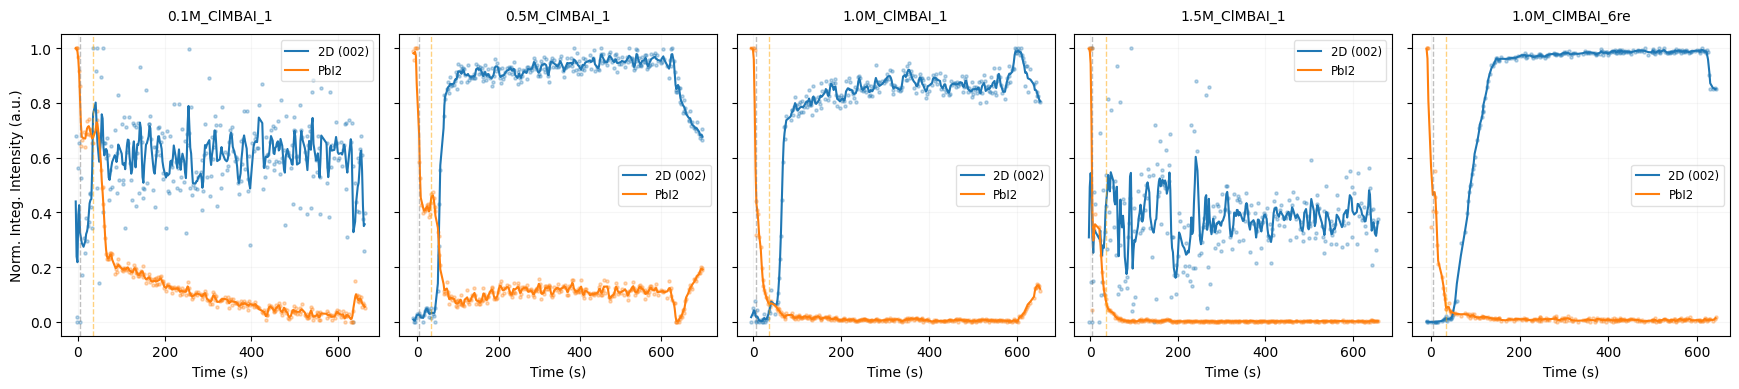

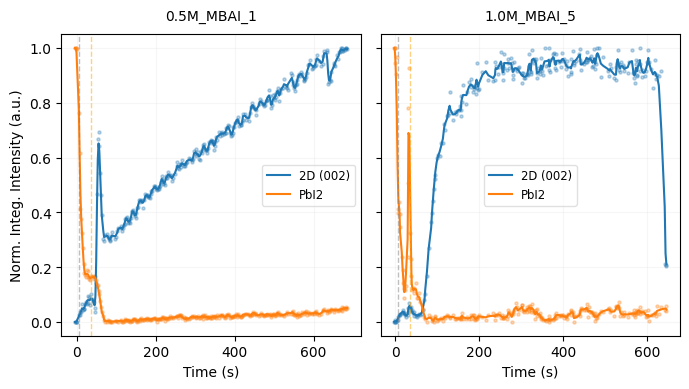

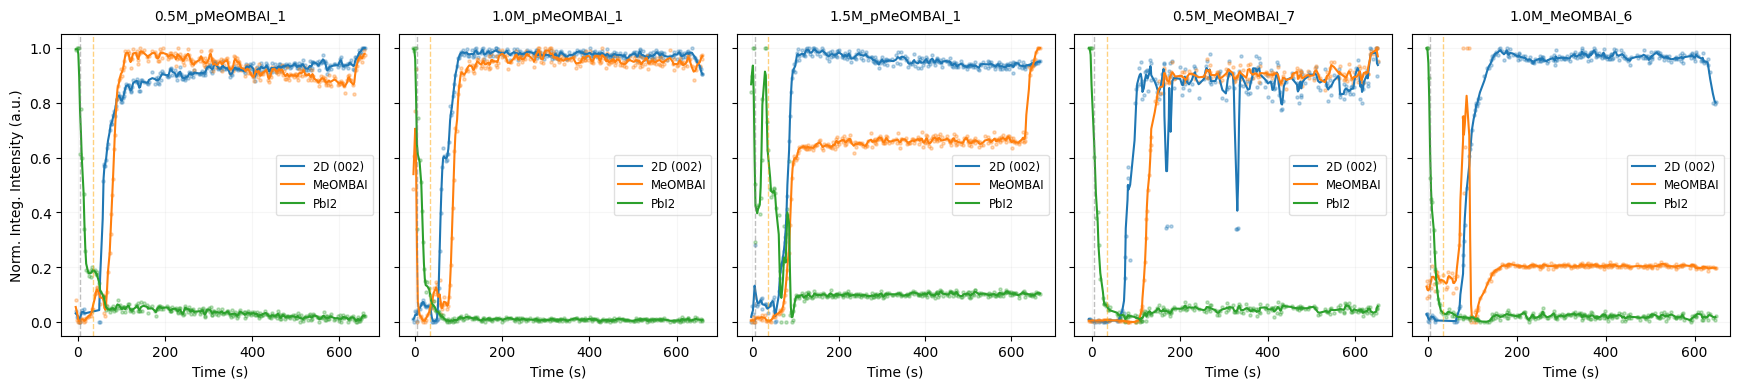

In [7]:
import matplotlib.pyplot as plt
import re
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Cell 14: Visualization of Peak Evolution
# -------------------------------------------------------------------------

# Groups to plot together
groups = ['ClMBAI', 'MBAI', 'p?MeOMBAI']

for group_motif in groups:
    # 1. Filter experiments matching the group
    matched_experiments = []
    for exp_name in sorted(merged_dfs.keys()):
        if re.search(f"M_{group_motif}", exp_name, re.IGNORECASE):
            matched_experiments.append(exp_name)
            
    num_exps = len(matched_experiments)
    if num_exps == 0:
        continue

    # 2. Setup Plot
    fig, axes = plt.subplots(1, num_exps, figsize=(max(5, num_exps * 3.5), 4), sharey=True)
    if num_exps == 1:
        axes = [axes]
    
    # 3. Plot each experiment
    for i, exp_name in enumerate(matched_experiments):
        ax = axes[i]
        df = merged_dfs[exp_name]
        
        # Plot each phase found in the dataframe
        for column in df.columns:
            # Get data and drop NaNs (some peaks might not be found in all frames)
            series = df[column].dropna()
            if series.empty:
                continue

            # Filtering and Normalization
            # Remove extreme outliers for better plotting scale
            lower_bound = np.percentile(series, 1)
            upper_bound = np.percentile(series, 99)
            clipped = series.clip(lower_bound, upper_bound)
            
            # Min-Max Normalize
            denom = (clipped.max() - clipped.min())
            if denom == 0: denom = 1
            norm_data = (clipped - clipped.min()) / denom
            
            ax.scatter(norm_data.index, norm_data, alpha=0.3, s=5)
            
            # Smoothing
            # Sigma=1 roughly smooths over +/- 1 second if data is 1s resolution
            smooth_data = gaussian_filter1d(norm_data, sigma=1)
            ax.plot(norm_data.index, smooth_data, linewidth=1.5, label=column)
        
        # Formatting
        clean_title = exp_name.replace("p", ".", 1).replace("insitu_", "")
        ax.set_title(clean_title, y=1.02, fontsize=10)
        ax.set_xlabel("Time (s)")
        
        if i == 0:
            ax.set_ylabel("Norm. Integ. Intensity (a.u.)")
        
        # Markers for experiment events
        ax.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=1) # Dispense
        ax.axvline(35, color='orange', linestyle='--', alpha=0.5, linewidth=1) # Heating
        
        ax.legend(fontsize='small', framealpha=0.6)
        ax.grid(True, alpha=0.1)

    plt.tight_layout()
    plt.show()

In [9]:
result_dfs

{np.str_('0p1M_ClMBAI_1'): PeakName  2D (002)      PbI2
 Time                        
 -5.0     -0.005119  0.245971
 -3.0     -0.004749  0.241881
 -1.0     -0.006618  0.245869
  1.0     -0.005129  0.224424
  3.0     -0.002206  0.216157
 ...            ...       ...
  653.0   -0.001815  0.085304
  655.0   -0.002500  0.079595
  657.0   -0.004904  0.081887
  659.0   -0.006140  0.080605
  661.0   -0.004723  0.079198
 
 [273 rows x 2 columns],
 np.str_('0p5M_ClMBAI_1'): PeakName  2D (002)      PbI2
 Time                        
 -9.0     -0.005938  0.233362
 -7.0     -0.003480  0.227136
 -5.0     -0.005832  0.247504
 -3.0     -0.006040  0.241041
 -1.0     -0.007727  0.250335
 ...            ...       ...
  693.0    0.122724  0.092225
  695.0    0.120569  0.092678
  697.0    0.121560  0.096292
  699.0    0.125249  0.095487
  701.0    0.119136  0.094134
 
 [281 rows x 2 columns],
 np.str_('0p5M_MBAI_1'): PeakName  2D (002)      PbI2
 Time                        
 -5.0      0.001790  0.121296


In [ ]:
import pandas as pd

# Bridge Cell: Adapt New Results to Old Plotting Variables
# -------------------------------------------------------
# The new 'process_time_series_by_peak' function returns DataFrames with 
# columns already named by the peak (e.g. "PbI2").
# The old workflow needed a merging step to convert 2-theta bins to names.
# We can skip that logic and simply use the results directly.

merged_dfs = result_dfs

# Create global merged view for inspection
if merged_dfs:
    final_merged_df = pd.concat(merged_dfs, axis=1)
    final_merged_df.columns.names = ['experiment', 'phase']

    print("Merged Data (Top 5 rows):")
    display(final_merged_df.head())
else:
    print("No results to merge.")

Experiment: 0p1M_ClMBAI_1 (Matched: ClMBAI)
  Target '2D (002)' (6.1): Merging columns [5.5, 5.7]
  Target 'PbI2' (13.3): Merging columns [13.2, 13.3, 13.4]
Experiment: 0p5M_ClMBAI_1 (Matched: ClMBAI)
  Target '2D (002)' (6.1): Merging columns [6.2, 6.3]
  Target 'PbI2' (13.3): Merging columns [13.1, 13.2, 13.3]
Experiment: 0p5M_MBAI_1 (Matched: MBAI)
  Target '2D (002)' (6.9): Merging columns [6.9, 7.0]
  Target 'PbI2' (13.3): Merging columns [13.2, 13.3, 13.9]
Experiment: 0p5M_pMeOMBAI_1 (Matched: p?MeOMBAI)
  Target '2D (002)' (6.1): Merging columns [6.2]
  Target 'PbI2' (13.3): Merging columns [12.8, 13.2, 13.3]
  Target 'MeOMBAI' (7.0): Merging columns [7.0]
Experiment: 1p0M_ClMBAI_1 (Matched: ClMBAI)
  Target '2D (002)' (6.1): Merging columns [6.5, 7.1]
  Target 'PbI2' (13.3): Merging columns [13.3, 13.4]
Experiment: 1p0M_pMeOMBAI_1 (Matched: p?MeOMBAI)
  Target '2D (002)' (6.1): Merging columns [6.0, 6.1]
  Target 'PbI2' (13.3): Merging columns [13.2, 13.5, 13.7, 13.8, 13.9, 14.

In [9]:
# Merge all experiments into a single DataFrame with MultiIndex columns
final_merged_df = pd.concat(merged_dfs, axis=1)

# name the top-level index as 'Experiment' and the second-level index as 'Phase'
final_merged_df.columns.names = ['experiment', 'phase']

final_merged_df

experiment 0p1M_ClMBAI_1           0p5M_ClMBAI_1           0p5M_MBAI_1  \
phase           2D (002)      PbI2      2D (002)      PbI2    2D (002)   
Time                                                                     
-5.0                 0.0  0.247519           0.0  0.239866         0.0   
-3.0                 0.0  0.243292           0.0  0.238355         0.0   
-1.0                 0.0  0.227951           0.0  0.245689         0.0   
 1.0                 0.0  0.217051           NaN       NaN         0.0   
 3.0                 0.0  0.216354           NaN       NaN         NaN   
...                  ...       ...           ...       ...         ...   
 126.0               NaN       NaN           NaN       NaN         NaN   
 156.0               NaN       NaN           NaN       NaN         NaN   
 188.0               NaN       NaN           NaN       NaN         NaN   
 238.0               NaN       NaN           NaN       NaN         NaN   
 258.0               NaN       NaN           NaN       NaN         NaN   

experiment           0p5M_pMeOMBAI_1                   1p0M_ClMBAI_1  ...  \
phase           PbI2        2D (002) MeOMBAI      PbI2      2D (002)  ...   
Time                                                                  ...   
-5.0        0.119312             0.0     0.0  0.044351           0.0  ...   
-3.0        0.119686             NaN     NaN       NaN           NaN  ...   
-1.0        0.109662             0.0     0.0  0.045712           0.0  ...   
 1.0        0.112451             0.0     0.0  0.055736           0.0  ...   
 3.0             NaN             0.0     0.0  0.053126           0.0  ...   
...              ...             ...     ...       ...           ...  ...   
 126.0           NaN             NaN     NaN       NaN           NaN  ...   
 156.0           NaN             NaN     NaN       NaN           NaN  ...   
 188.0           NaN             NaN     NaN       NaN           NaN  ...   
 238.0           NaN             NaN     NaN       NaN           NaN  ...   
 258.0           NaN             NaN     NaN       NaN           NaN  ...   

experiment 1p5M_ClMBAI_1 1p5M_pMeOMBAI_1                    \
phase               PbI2        2D (002) MeOMBAI      PbI2   
Time                                                         
-5.0                 NaN             NaN     NaN       NaN   
-3.0            0.230522             0.0     0.0  0.048765   
-1.0            0.233805             0.0     0.0  0.053401   
 1.0            0.260000             0.0     0.0  0.062736   
 3.0            0.268577             0.0     0.0  0.060966   
...                  ...             ...     ...       ...   
 126.0               NaN             NaN     NaN       NaN   
 156.0               NaN             NaN     NaN       NaN   
 188.0               NaN             NaN     NaN       NaN   
 238.0               NaN             NaN     NaN       NaN   
 258.0               NaN             NaN     NaN       NaN   

experiment insitu_0p5M_MeOMBAI_7 insitu_1p0M_ClMBAI_6re            \
phase                       PbI2               2D (002)      PbI2   
Time                                                                
-5.0                    0.026212                    0.0  0.026801   
-3.0                    0.026631                    NaN       NaN   
-1.0                    0.026183                    NaN       NaN   
 1.0                         NaN                    NaN       NaN   
 3.0                         NaN                    NaN       NaN   
...                          ...                    ...       ...   
 126.0                       NaN                    NaN       NaN   
 156.0                       NaN                    NaN       NaN   
 188.0                       NaN                    NaN       NaN   
 238.0                       NaN                    NaN       NaN   
 258.0                       NaN                    NaN       NaN   

experiment insitu_1p0M_MBAI_5           insitu_1

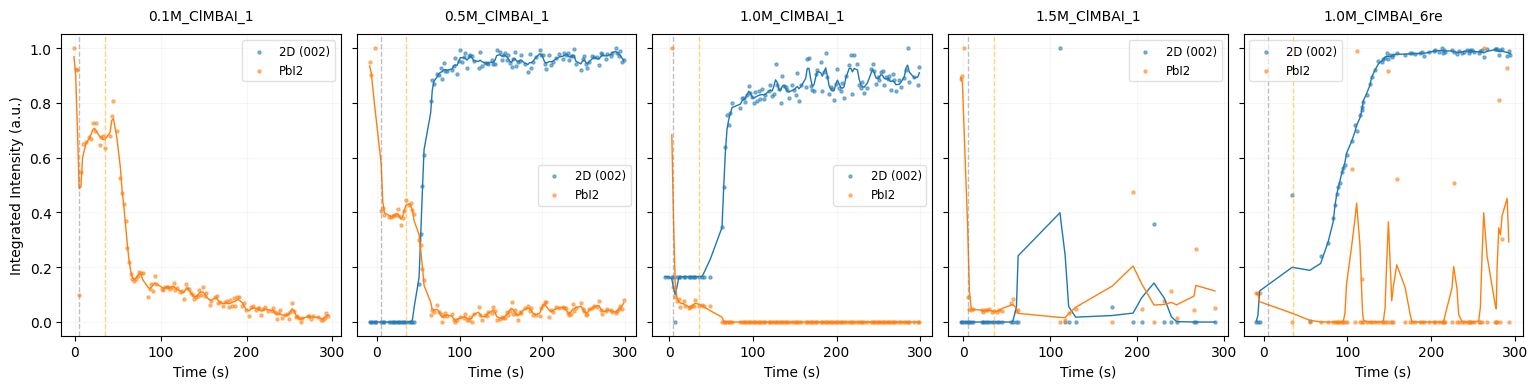

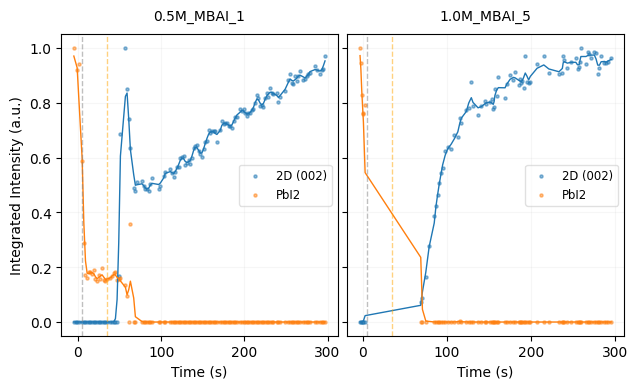

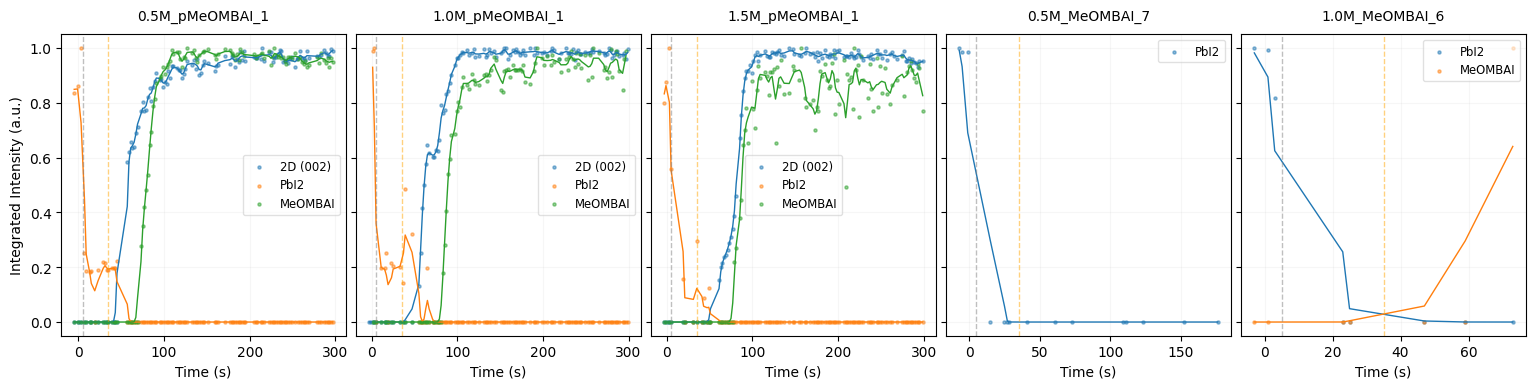

In [17]:
import matplotlib.pyplot as plt
import re
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Groups to plot together, matching the structure in giwaxs.ipynb
groups = ['ClMBAI', 'MBAI', 'p?MeOMBAI']

for group_motif in groups:
    # 1. Filter experiments matching the group
    matched_experiments = []
    # Sort keys to ensure consistent order
    for exp_name in sorted(merged_dfs.keys()):
        # The regex logic from giwaxs.ipynb
        if re.search(f"M_{group_motif}", exp_name, re.IGNORECASE):
            matched_experiments.append(exp_name)
            
    num_exps = len(matched_experiments)
    if num_exps == 0:
        continue

    # 2. Setup Plot
    fig, axes = plt.subplots(1, num_exps, figsize=(num_exps * 3 + 0.5, 4), sharey=True)
    if num_exps == 1:
        axes = [axes]
    
    # 3. Plot each experiment
    for i, exp_name in enumerate(matched_experiments):
        ax = axes[i]
        df = merged_dfs[exp_name]
        
        # Plot each phase found in the dataframe
        for column in df.columns:
            # remove outliers beyond 1st and 99th percentiles
            lower_bound = np.percentile(df[column], 1)
            upper_bound = np.percentile(df[column], 99)
            df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
            # min-max normalize
            df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
            ax.scatter(df.index, df[column], label=column, alpha=0.5, s=5)
            # use gaussian smoothing
            smooth_data = gaussian_filter1d(df[column], sigma=1)
            ax.plot(df.index, smooth_data, linewidth=1)
        
        # Formatting
        # Clean up title: replace 'p' with '.' for concentration (1p0 -> 1.0), remove prefix
        clean_title = exp_name.replace("p", ".", 1).replace("insitu_", "")
        ax.set_title(clean_title, y=1.02, fontsize=10)
        
        ax.set_xlabel("Time (s)")
        if i == 0:
            ax.set_ylabel("Integrated Intensity (a.u.)")
        
        # Add experiment markers (Dispense and Heating)
        ax.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=1) # Dispense
        ax.axvline(35, color='orange', linestyle='--', alpha=0.5, linewidth=1) # Heating
        
        ax.legend(fontsize='small', framealpha=0.6)
        ax.grid(True, alpha=0.1)

    plt.tight_layout(w_pad=0.02)
    plt.show()

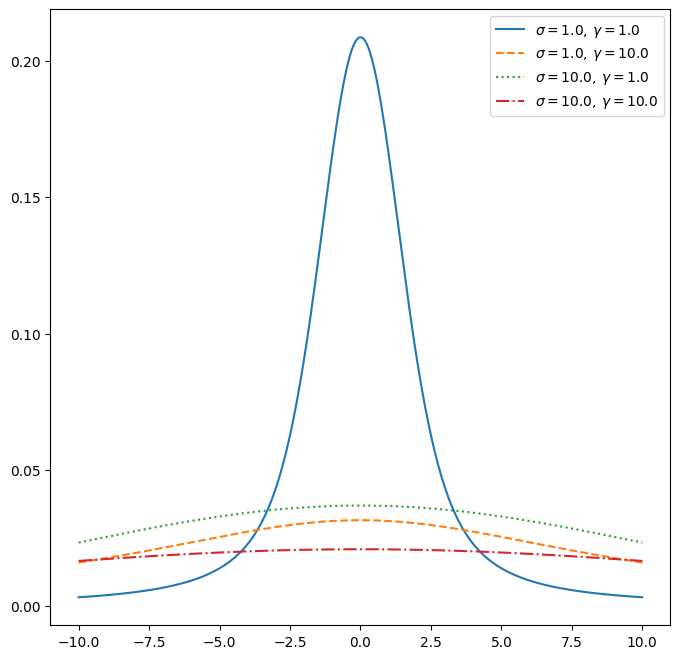

In [179]:
from scipy.special import voigt_profile
import numpy as np
import matplotlib.pyplot as plt
voigt_profile(2, 1., 1.)

fig, ax = plt.subplots(figsize=(8, 8))
x = np.linspace(-10, 10, 500)
parameters_list = [(1., 1., "solid"), (1., 10., "dashed"),
                   (10., 1., "dotted"), (10., 10., "dashdot")]
for params in parameters_list:
    sigma, gamma, linestyle = params
    voigt = voigt_profile(x, sigma, gamma)
    ax.plot(x, voigt, label=rf"$\sigma={sigma},\, \gamma={gamma}$",
            ls=linestyle)
ax.legend()
plt.show()